In [1]:
import utils
import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

2026-02-13 21:37:39.048533: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 21:37:39.424104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771015059.592526   13721 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771015059.642804   13721 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 21:37:39.999521: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
(train_x, train_y), (test_x, test_y) = utils.read_gate_one_data()

datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg /data/upload/3/e82f4a47-black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/upload/3/c94577a6-Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg


(3685, 300, 300, 3)
(3685,)
(650, 300, 300, 3)
(650,)
[1 0 1 ... 0 0 0]


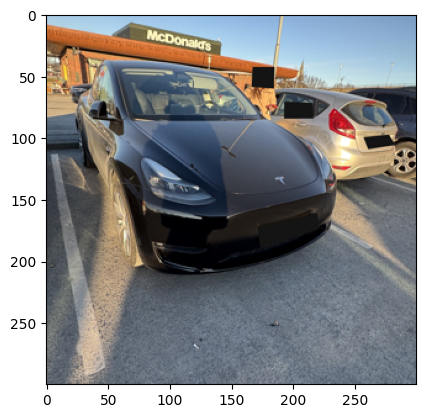

In [3]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

i = 93
print(train_y)
plt.imshow(train_x[i])
plt.show()

In [4]:
i = 0

1


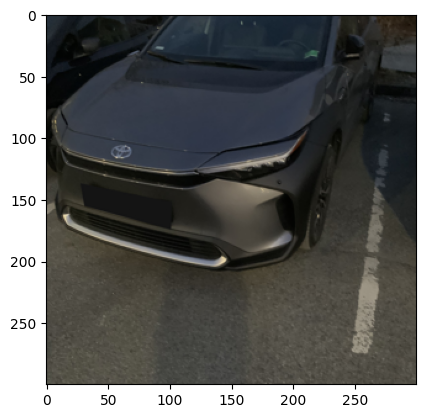

In [5]:

print(train_y[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [6]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y,
    epochs=epochs,
)

I0000 00:00:1771015346.237661   13721 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


I0000 00:00:1771015352.645587   14678 service.cc:148] XLA service 0x767f3000a030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771015352.646789   14678 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-13 21:42:32.715775: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771015352.884002   14678 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/116 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4603 - loss: 0.9444

I0000 00:00:1771015357.560127   14678 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6904 - loss: 0.5922
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8000 - loss: 0.4399
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8624 - loss: 0.3404
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8963 - loss: 0.2661
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9444 - loss: 0.1709


In [7]:
functional_model.evaluate(test_x, test_y)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7677 - loss: 0.5422


[0.5421808958053589, 0.7676923274993896]

In [8]:
for x, y in zip(test_x, test_y):
    print(functional_model.predict(x[None, ...]) > 0.5, y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[False]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[ True]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[ True]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[False]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[ True]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[ True]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[False]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[False]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[False]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[ True]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[ True]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[False]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[False]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[ True]] 1